<a href="https://colab.research.google.com/github/RonShan03/ModularRNNProj/blob/change-hidden-dimensions/Copy_of_train_rnn_modular_addition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qqq einops

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

import torch.nn.functional as F
import torch.optim as optim
import einops
import os
import copy
import tqdm

In [3]:
MODULO = 113
TRAIN_FACTOR = 0.3
HIDDEN_DIM = 512
NUM_HIDDEN_LAYERS = 1
INTERVAL = 100

NUM_EPOCHS = 20000
lr = 0.01
wd = 5e-5
betas = (0.9, 0.99)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [5]:
a_vector = einops.repeat(torch.arange(MODULO), "i -> (i j)", j=MODULO)
b_vector = einops.repeat(torch.arange(MODULO), "j -> (i j)", i=MODULO)
equals_vector = einops.repeat(torch.tensor(MODULO), " -> (i j)", i=MODULO, j=MODULO)
dataset = torch.stack([a_vector, b_vector, equals_vector], dim=1)
labels = (dataset[:, 0] + dataset[:, 1]) % MODULO

print(dataset.shape)
print(labels.shape)
print(dataset[:5])
print(labels[:5])

torch.Size([12769, 3])
torch.Size([12769])
tensor([[  0,   0, 113],
        [  0,   1, 113],
        [  0,   2, 113],
        [  0,   3, 113],
        [  0,   4, 113]])
tensor([0, 1, 2, 3, 4])


In [6]:
DATA_SEED = 598

torch.manual_seed(DATA_SEED)
indices = torch.randperm(MODULO*MODULO)
cutoff = int(MODULO*MODULO*TRAIN_FACTOR)
train_indices = indices[:cutoff]
test_indices = indices[cutoff:]

train_data = dataset[train_indices]
train_labels = labels[train_indices]
test_data = dataset[test_indices]
test_labels = labels[test_indices]
print(train_data[:5])
print(train_labels[:5])
print(train_data.shape)
print(test_data[:5])
print(test_labels[:5])
print(test_data.shape)

train_data = train_data.to(device)
train_labels = train_labels.to(device)
test_data = test_data.to(device)
test_labels = test_labels.to(device)

tensor([[ 21,  31, 113],
        [ 30,  98, 113],
        [ 47,  10, 113],
        [ 86,  21, 113],
        [ 99,  83, 113]])
tensor([ 52,  15,  57, 107,  69])
torch.Size([3830, 3])
tensor([[ 43,  40, 113],
        [ 31,  42, 113],
        [ 39,  63, 113],
        [ 35,  61, 113],
        [112, 102, 113]])
tensor([ 83,  73, 102,  96, 101])
torch.Size([8939, 3])


In [7]:
class RNNModel(nn.Module):
    def __init__(self, hidden_dim, n_layers, vocab_size):
        super(RNNModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.layer_dim = n_layers
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, n_layers, batch_first=True) # batch_first=True (batch_dim, seq_dim, feature_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.bn = nn.BatchNorm1d(hidden_dim)

    def forward(self, tokens):
        xs = self.embedding(tokens)
        hs, hn = self.rnn(xs)
        hs = self.bn(hs[:, -1, :])
        scores = self.fc(hs)
        return scores

model = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
if device == "cuda":
    model = model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd, betas=betas)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=torch.arange(5000, 25000, step=5000), gamma=0.1)

In [8]:
def loss_fn(logits, labels):
    if len(logits.shape)==3:
        logits = logits[:, -1]
    logits = logits.to(torch.float64)
    log_probs = logits.log_softmax(dim=-1)
    correct_log_probs = log_probs.gather(dim=-1, index=labels[:, None])[:, 0]
    return -correct_log_probs.mean()

In [9]:
train_losses = []
test_losses = []
model_checkpoints = []
checkpoint_epochs = []
checkpoint_train = []
checkpoint_test = []

for epoch in tqdm.tqdm(range(NUM_EPOCHS)):
    train_logits = model(train_data)
    train_loss = loss_fn(train_logits, train_labels)
    train_loss.backward()
    train_losses.append(train_loss.item())

    optimizer.step()
    optimizer.zero_grad()
    # scheduler.step()

    with torch.inference_mode():
        test_logits = model(test_data)
        test_loss = loss_fn(test_logits, test_labels)
        test_losses.append(test_loss.item())

    if ((epoch+1)%INTERVAL)==0:
        checkpoint_epochs.append(epoch)
        checkpoint_train.append(train_loss.item())
        checkpoint_test.append(test_loss.item())
        model_checkpoints.append(copy.deepcopy(model.state_dict()))
        print(f"Epoch {epoch}\t\tTrain Loss {train_loss.item()}\t\tTest Loss {test_loss.item()}")

  0%|          | 100/20000 [00:44<2:11:17,  2.53it/s]

Epoch 99		Train Loss 0.0008417592099647471		Test Loss 14.785524592350999


  1%|          | 200/20000 [01:24<2:25:33,  2.27it/s]

Epoch 199		Train Loss 1.836939888228218		Test Loss 12.263645475089023


  2%|▏         | 300/20000 [02:05<2:08:45,  2.55it/s]

...

Epoch 19799		Train Loss 0.0010531396154483217		Test Loss 0.0015727631625196692


100%|█████████▉| 19900/20000 [2:11:53<00:36,  2.75it/s]

Epoch 19899		Train Loss 0.0009406311828044656		Test Loss 0.0012882630121860397


100%|██████████| 20000/20000 [2:12:30<00:00,  2.52it/s]

Epoch 19999		Train Loss 0.0010392235468676203		Test Loss 0.0013165315498494439


In [11]:
import os
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

PTH_LOCATION = f"workspace/_scratch/grokking_rnn_large_{HIDDEN_DIM}_{TRAIN_FACTOR}.pth"

Mounted at /content/drive


In [12]:
# Create the directory if it does not exist
# os.makedirs(Path(PTH_LOCATION).parent, exist_ok=True) # original line
os.makedirs(os.path.dirname("/content/drive/MyDrive/" + PTH_LOCATION), exist_ok=True) # changed line to create all parent directories

torch.save(
    {
        "model":model.state_dict(),
        "checkpoints": model_checkpoints,
        "checkpoint_epochs": checkpoint_epochs,
        "test_losses": test_losses,
        "train_losses": train_losses,
        "train_indices": train_indices,
        "test_indices": test_indices,
        "checkpoint_train": checkpoint_train,
        "checkpoint_test": checkpoint_test
    },
    "/content/drive/MyDrive/" + PTH_LOCATION)

In [13]:
# evaluation function that provides the accuracy of the model
def evaluate(model, data, labels):
    with torch.no_grad():
        logits = model(data)
        predictions = logits.argmax(dim=-1)
        correct = (predictions == labels).sum().item()
        total = len(labels)
        accuracy = correct / total * 100
        return accuracy

# evaluate the model on the test set
evaluation = evaluate(model, test_data, test_labels)
print(f"Test Accuracy: {evaluation}%")

Test Accuracy: 100.0%


<Axes: xlabel='Epoch'>

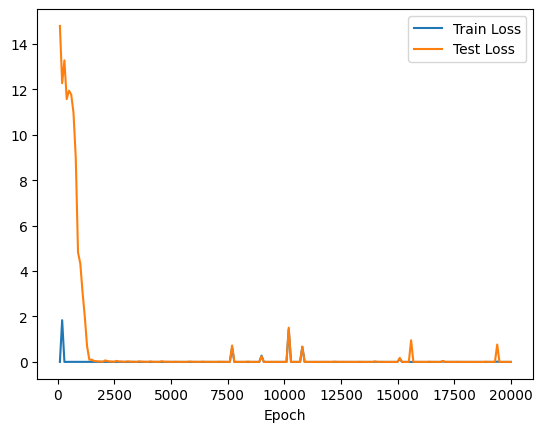

In [14]:
# plot train_loss and test_loss with each other against epoch
fig, ax = plt.subplots() # Create the figure and axes object

df = pd.DataFrame({'Train Loss': checkpoint_train, 'Test Loss': checkpoint_test, 'Epoch': checkpoint_epochs})
df.plot(x='Epoch', y=['Train Loss', 'Test Loss'], ax=ax)